## LIBRERÍA

In [2]:
! pip install pyreadr
!conda install -y pyarrow
import geopandas as gpd
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda




## 1.CONEXIÓN BASE DE DATOS

In [5]:
RUTA_CENSO_ZONAL = "../Parquet/Cartografía_censo2024_R13_Zonal.parquet"

In [6]:
censo_zonal = gpd.read_parquet(RUTA_CENSO_ZONAL)

## 2.ESTUDIO DE VARIABLES

In [7]:
for col in sorted(censo_zonal.columns):
    print(col)

AREA_C
CATEGORIA
COD_CATEGORIA
COD_DISTRITO
COD_ENTIDAD
COD_LOCALIDAD
COD_PROVINCIA
COD_REGION
COD_ZONA
COMUNA
CUT
DISTRITO
ENTIDAD
ID_DISTRITO
ID_ENTIDAD
ID_LOCALIDAD
ID_ZONA
LOCALIDAD
OBJECTID
PROVINCIA
REGION
SHAPE
SHAPE_Area
SHAPE_Length
n_afrodescendencia
n_analfabet
n_asistencia_basica
n_asistencia_media
n_asistencia_parv
n_asistencia_superior
n_basura_entierra
n_basura_eriazo
n_basura_otro
n_basura_rio
n_basura_servicios
n_caenes_A
n_caenes_B
n_caenes_C
n_caenes_D
n_caenes_E
n_caenes_F
n_caenes_G
n_caenes_H
n_caenes_I
n_caenes_J
n_caenes_K
n_caenes_L
n_caenes_M
n_caenes_N
n_caenes_O
n_caenes_P
n_caenes_Q
n_caenes_R
n_caenes_S
n_caenes_T
n_caenes_U
n_cine_especial_diferencial
n_cine_nunca_curso_primera_infancia
n_cine_primaria
n_cine_secundaria
n_cine_terciaria_maestria_doctorado
n_cise_rec_dependientes
n_cise_rec_independientes
n_cise_rec_trabajador_no_remunerado
n_ciuo_0
n_ciuo_1
n_ciuo_2
n_ciuo_3
n_ciuo_4
n_ciuo_5
n_ciuo_6
n_ciuo_7
n_ciuo_8
n_ciuo_9
n_comb_calefaccion_carbon
n

In [8]:
# 2. Filtrar las comunas de la Provincia de Melipilla
comunas_melipilla = ['MELIPILLA', 'MARÍA PINTO', 'CURACAVÍ', 'ALHUÉ', 'SAN PEDRO']
gdf_mel_2024 = censo_zonal[censo_zonal['COMUNA'].str.upper().isin(comunas_melipilla)].copy()

## 3.EDA

## 4.MAPA

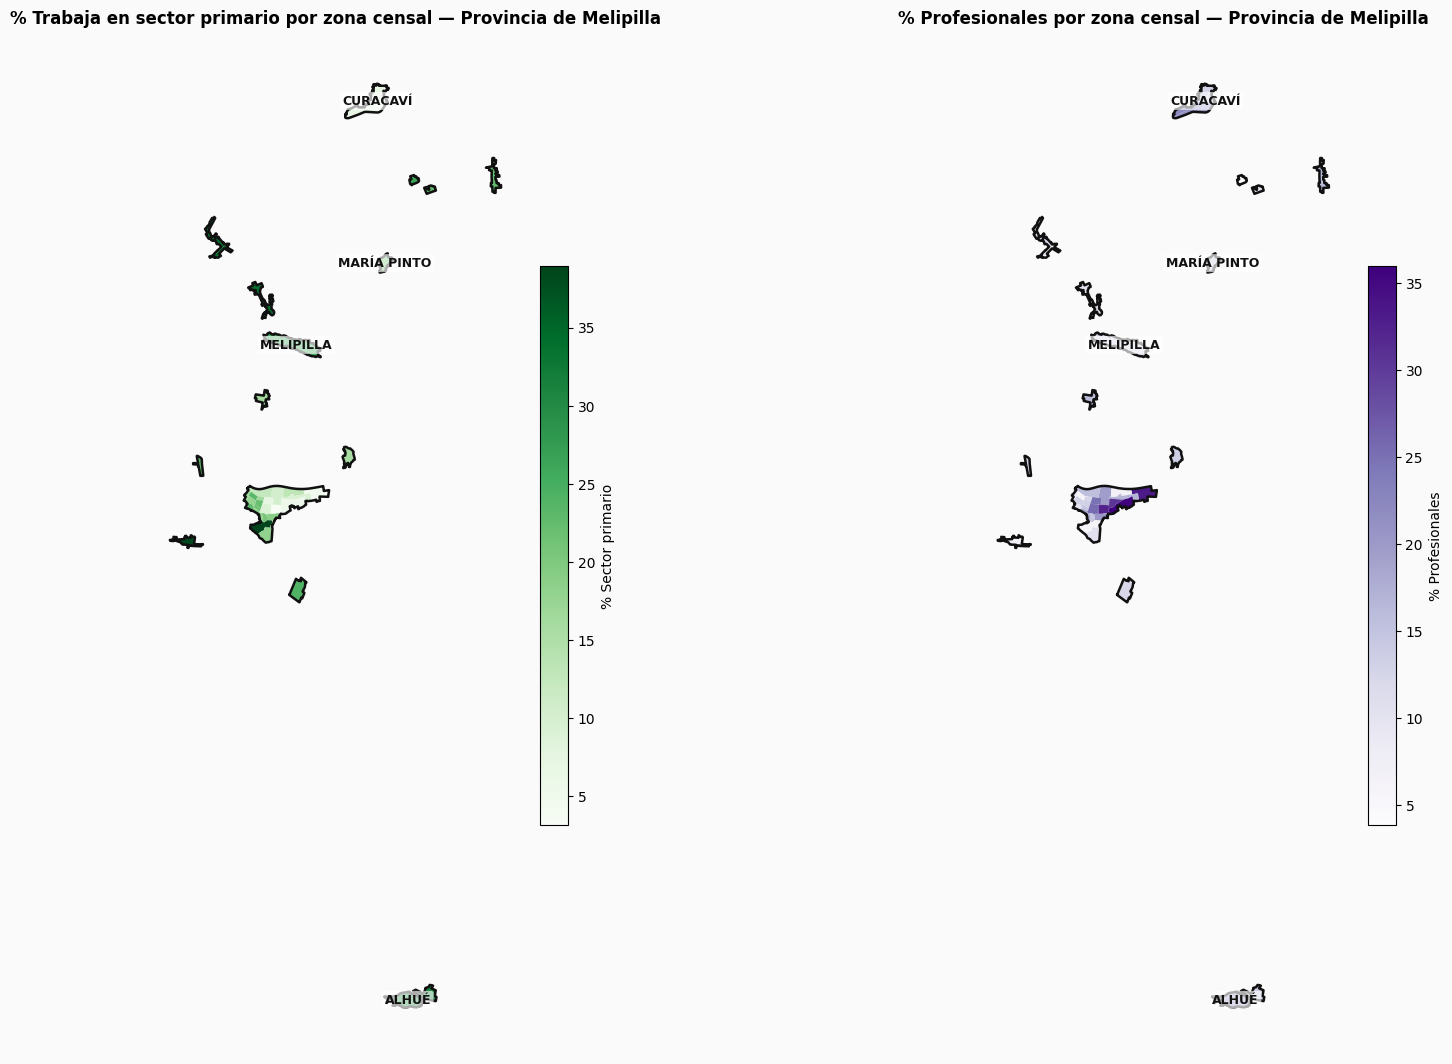

In [10]:
# Calcular porcentajes
gdf_mel_2024['sector_primario'] = (
    (gdf_mel_2024['n_caenes_A'] + gdf_mel_2024['n_caenes_B']) / gdf_mel_2024['n_ocupado']
).fillna(0) * 100

gdf_mel_2024['porcentaje_profesionales'] = (
    gdf_mel_2024['n_cine_terciaria_maestria_doctorado'] / gdf_mel_2024['n_per']
).fillna(0) * 100

def plot_univariado(ax, gdf_z, gdf_c, gdf_ct, col, cmap, titulo, cbar_label):
    gdf_z.plot(
        column=col, ax=ax, cmap=cmap, linewidth=0,
        legend=True,
        legend_kwds={'label': cbar_label, 'shrink': 0.55, 'pad': 0.02}
    )
    gdf_c.plot(ax=ax, facecolor='none', edgecolor='#111', linewidth=1.8)
    for _, row in gdf_ct.iterrows():
        ax.annotate(
            row['nom_comuna'],
            xy=(row.geometry.x, row.geometry.y),
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='#111',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65, ec='none')
        )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')

# 2. CAPA DE LÍMITES COMUNALES (Bordes gruesos)
# Disolvemos las zonas para crear los polígonos grandes de cada comuna
gdf_comunas_2024 = gdf_mel_2024.dissolve(by='COMUNA').reset_index()


# 3. CAPA DE ETIQUETAS (Textos al centro)
# Tomamos los polígonos comunales y calculamos su punto representativo
gdf_puntos_2024 = gdf_comunas_2024.copy()
gdf_puntos_2024['geometry'] = gdf_puntos_2024.geometry.representative_point()
gdf_puntos_2024 = gdf_puntos_2024.rename(columns={'COMUNA': 'nom_comuna'})


# 4. GRAFICAR
fig, axes = plt.subplots(1, 2, figsize=(20, 11))
fig.patch.set_facecolor('#fafafa')

# Mapa Izquierdo: Sector Primario
plot_univariado(
    ax=axes[0], 
    gdf_z=gdf_mel_2024,           # Capa de zonas (color)
    gdf_c=gdf_comunas_2024,       # Capa comunal (bordes negros)
    gdf_ct=gdf_puntos_2024,       # Capa de puntos (textos)
    col='sector_primario', 
    cmap='Greens',
    titulo='% Trabaja en sector primario por zona censal — Provincia de Melipilla',
    cbar_label='% Sector primario'
)

# Mapa Derecho: Profesionales
plot_univariado(
    ax=axes[1], 
    gdf_z=gdf_mel_2024,           # Capa de zonas (color)
    gdf_c=gdf_comunas_2024,       # Capa comunal (bordes negros)
    gdf_ct=gdf_puntos_2024,       # Capa de puntos (textos)
    col='porcentaje_profesionales', 
    cmap='Purples',
    titulo='% Profesionales por zona censal — Provincia de Melipilla',
    cbar_label='% Profesionales'
)

# Eliminar los ejes de coordenadas que sobran
for ax in axes:
    ax.set_axis_off()

plt.tight_layout(pad=2)
plt.show()